# QCoDeS example with Zurich Instruments MFLI and UHFLI

The [MFLI](https://www.zhinst.com/europe/en/products/mfli-lock-in-amplifier/) and [UHFLI](https://www.zhinst.com/europe/en/products/uhfli-lock-in-amplifier/) are lock-in amplifiers with different frequency ranges but similar control 
is notebook shows how to connect to either lock-in, set individual parameters,
read X, Y, R and Theta, and save point measurements and time traces with QCoDeS.
It uses the base instruments, without licensed options.

## Connect to the instrument

1. Make sure you have [LabOne](https://www.zhinst.com/europe/en/instruments/labone/labone-instrument-control-software/) installed on your computer.
2. Make sure you have QCoDeS set up (see the [QCoDeS website](https://microsoft.github.io/Qcodes/index.html) or my notebook [14 minutes to QCoDeS](https://github.com/lairdgrouplancaster/14-minutes-to-QCoDeS/blob/main/14_minutes_to_QCoDeS.ipynb)).
3. In this repository's Python environment, execute `pip install zhinst`.
4. Connect the instrument by USB, start LabOne on your computer, and check that your lockin appears there.
5. Set `MODEL` and `DEVICE` below for your instrument.
6. Open LabOne on your computer. This can run at the same time as this notebook, and lets you monitor the effect of Python commands.
7. A good testing configuration is to connect Signal Output +V to Signal Input +V (on the MFLI) or Signal Output 1 to Signal Input 1 (on the UHFLI) via a Minicircuits BLP-1.9+ filter. The phase shift is about 64 degrees to 500 kHz. If you don't have a filter, you can use a cable; the phase shift to 500 kHz is a fraction of a degree, but measurable.

In [1]:
from qcodes_contrib_drivers.drivers.ZurichInstruments.MFLI import MFLI
from qcodes_contrib_drivers.drivers.ZurichInstruments.UHFLI import UHFLI

MODEL = "MFLI"              # "UHFLI" or "MFLI".
DEVICE = "dev7920"          # Change to the device ID of your instrument.
HOST = "192.168.123.194"    # You can find this using the MF Device Finder utility.

if MODEL == "MFLI":
    lia = MFLI("mfli", DEVICE, HOST, port=8004)
elif MODEL == "UHFLI":
    lia = UHFLI("uhfli", DEVICE, HOST, port=8004, interface="USB")
else:
    raise ValueError("MODEL must be MFLI or UHFLI")

lia.get_idn()

{'vendor': 'Zurich Instruments',
 'model': 'MFLI',
 'serial': 'dev7920',
 'firmware': 71177}

## Initialise QCoDeS control

Station and experiment setup:

In [2]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qcodes.station import Station
from qcodes.dataset import (
    do0d, do1d, do2d,
    initialise_or_create_database_at,
    load_or_create_experiment,
)
from qcodes.parameters import MultiParameter

station = Station(lia)
data_directory = Path("example_output")
data_directory.mkdir(exist_ok=True)
initialise_or_create_database_at(str(data_directory / "zurich_lockins.db"))
experiment = load_or_create_experiment(
    experiment_name=f"testing_{MODEL.lower()}", sample_name="signal_source"
)

Set up the channels. Channel numbering is zero-based: demods[0] is channel 1 in LabOne.

`lia` is the QCoDeS instrument; the shorter names refer to its existing channels.

In [3]:
demod_index = 0
demod = lia.demods[demod_index]
oscillator = lia.oscs[0]
signal_input = lia.sigins[0]
signal_output = lia.sigouts[0]

## Set and read individual parameters
Turn output off and on. You should hear a click:

In [4]:
signal_output.on(0) # Turn output off

In [5]:
signal_output.on(1) # Turn output on

Read output state:

In [6]:
signal_output.on()

1

Set selected instrument parameters:

In [13]:
# Oscillator and demodulator configuration:
lia.extrefs[0].enable(0)  # Set oscillator 0 to use the internal reference.
oscillator.freq(1.23e3)

output_mixer = 1 if MODEL == "MFLI" else 3
output_reference = lia.demods[output_mixer]
output_reference.oscselect(0)
output_reference.harmonic(1)
output_reference.phaseshift(0.0)

# Signal input configuration:
signal_input.on(1)
signal_input.diff(0)     # Single-ended Signal Input 1.
signal_input.ac(0)       # DC coupling.
signal_input.imp50(0)    # High-impedance input.
signal_input.range(0.3)  # Analog input range, V.
signal_input.scaling(1.0)

# Signal output configuration:
signal_output.range(1.0)
signal_output.offset(0.0)
signal_output.imp50(0)   # Specify output amplitude assuming a high-impedance load.
signal_output.amplitude(0.010)
signal_output.amplitude_enabled(1) # Enable the sine-wave part of the output signal. (The offset is always enabled if the output is on.)

demod.adcselect(0)          # Signal Input 1
demod.oscselect(0)
demod.harmonic(1)
demod.phaseshift(0.0)
demod.order(3)              # Filter order
demod.timeconstant(0.010)   # Filter time constant (s)
demod.sinc(0)

demod.trigger(0)         # Continuous streaming.
demod.rate(1000)
demod.enable(1)
lia.configure_readout(demod=demod_index)  # Infer V for this unscaled voltage input.

Read selected instrument parameters:

In [8]:
print("Frequency:", oscillator.freq(), "Hz")
print("Amplitude:", signal_output.amplitude(), "V peak")
print("Phase:", demod.phaseshift(), "deg")
print("Input range:", signal_input.range(), "V")
print("Digital scaling:", signal_input.scaling())
print("Filter:", demod.order(), "poles;", demod.timeconstant(), "s")
print("Actual streaming rate:", demod.rate(), "samples/s")

Frequency: 1230.0000000919908 Hz
Amplitude: 0.0099945068359375 V peak
Phase: 0.0 deg
Input range: 0.30000001192092896 V
Digital scaling: 1.0
Filter: 3 poles; 0.01019437238574028 s
Actual streaming rate: 837.0535888671875 samples/s


### Digital gain and units

For example, apply a digital gain of ten and label the values accordingly.
`configure_readout` changes QCoDeS metadata; it does not multiply the values
again. Refresh this metadata **before starting a new dataset** after changing
source or scaling. Reads reject stale source/scaling metadata.

This cell returns to unit scaling for all the following examples. For an
unscaled MFLI current input (`adcselect=1`), unit inference instead gives amps;
UHFLI `adcselect=1` selects its second voltage input.

In [ ]:
try:
    signal_input.scaling(10.0)
    lia.configure_readout(demod=demod_index, unit="scaled V")
    time.sleep(settle_s)
    print("Scaled R:", demod.r(), demod.r.unit)
finally:
    signal_input.scaling(1.0)
    lia.configure_readout(demod=demod_index)
time.sleep(settle_s)

## Read individual data points
You can do this either by individual calls, or as a QCoDeS `Multiparameter`.
X, Y and R use RMS volts for the unscaled voltage input configured above; Theta is in degrees.

In [ ]:
# Acquire by individual calls:
x = demod.x()
print(f"X={x:g} V")
y = demod.y()
print(f"Y={y:g} V")
r = demod.r()
print(f"R={r:g} V")
theta = demod.theta()
print(f"Theta={theta:g} deg")

X=0.00707338 V
Y=-1.83681e-05 V
R=0.00707377 V
Theta=-0.146527 deg


In [11]:
# Acquire as a MultiParameter:
x, y, r, theta = demod.readout()
print(f"Combined reading: X={x:g}, Y={y:g}, R={r:g}, Theta={theta:g}")

Combined reading: X=0.00707363, Y=-1.84896e-05, R=0.00707366, Theta=-0.149764


## Sweeps
### Point-by-point acquisition
You can acquire point-by-point either by measuring one parameter at a time (as here in the do1d example) or by measuring a `Multiparameter` (as in the do2d example). The latter is more efficient because instrument communication is a bit faster.

Starting experimental run with id: 7. Using 'qcodes.dataset.do1d'


  0%|          | 0/101 [00:00<?, ?it/s]

(points_vs_frequency #7@c:\Users\lairde\OneDrive - Lancaster University\Desktop\Drivers\Qcodes_contrib_drivers\docs\examples\example_output\zurich_lockins.db
 ------------------------------------------------------------------------------------------------------------------------------------------------------------
 mfli_oscs0_freq - numeric
 mfli_demods0_r - numeric
 mfli_demods0_theta - numeric,
 (<Axes: title={'center': 'Run #7, Experiment testing_mfli (signal_source)'}, xlabel='freq (kHz)', ylabel='R (mV)'>,
  <Axes: title={'center': 'Run #7, Experiment testing_mfli (signal_source)'}, xlabel='freq (kHz)', ylabel='Theta (deg)'>),
 (None, None))

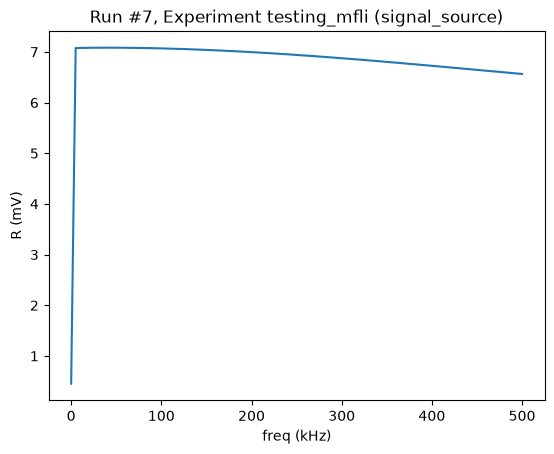

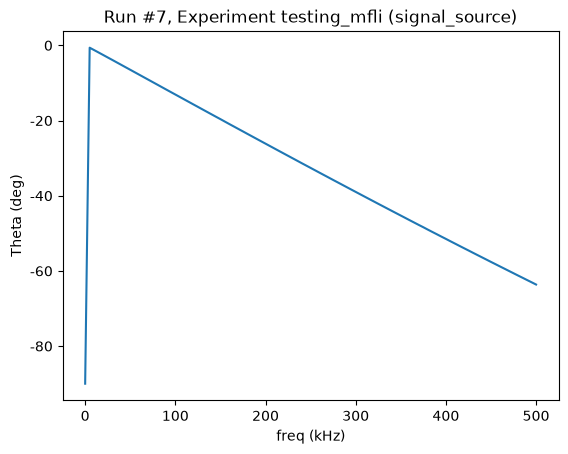

In [ ]:
do1d(
    oscillator.freq, 0, 500e3, 101, 0.1,
    demod.r, demod.theta,
    exp=experiment,
    measurement_name="points_vs_frequency",
    do_plot=True,
    show_progress=True,
)

Starting experimental run with id: 10. Using 'qcodes.dataset.do2d'


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

  0%|          | 0/51 [00:00<?, ?it/s]

(points_vs_amplitude_frequency #10@c:\Users\lairde\OneDrive - Lancaster University\Desktop\Drivers\Qcodes_contrib_drivers\docs\examples\example_output\zurich_lockins.db
 -----------------------------------------------------------------------------------------------------------------------------------------------------------------------
 mfli_sigouts0_amplitude - numeric
 mfli_oscs0_freq - numeric
 mfli_demods0_readout_x - numeric
 mfli_demods0_readout_y - numeric
 mfli_demods0_readout_r - numeric
 mfli_demods0_readout_theta - numeric,
 (<Axes: title={'center': 'Run #10, Experiment testing_mfli (signal_source)'}, xlabel='Peak amplitude (mV)', ylabel='freq (kHz)'>,
  <Axes: title={'center': 'Run #10, Experiment testing_mfli (signal_source)'}, xlabel='Peak amplitude (mV)', ylabel='freq (kHz)'>,
  <Axes: title={'center': 'Run #10, Experiment testing_mfli (signal_source)'}, xlabel='Peak amplitude (mV)', ylabel='freq (kHz)'>,
  <Axes: title={'center': 'Run #10, Experiment testing_mfli (signa

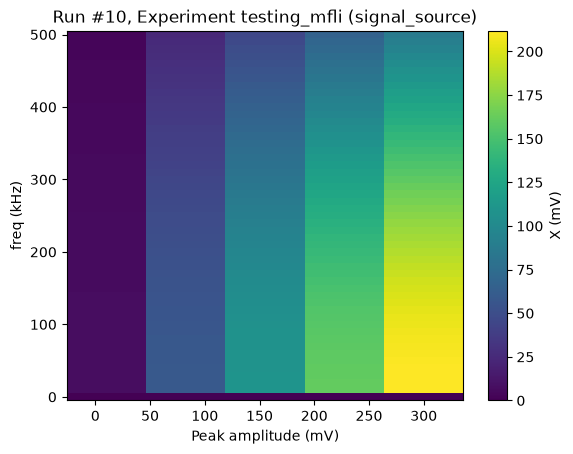

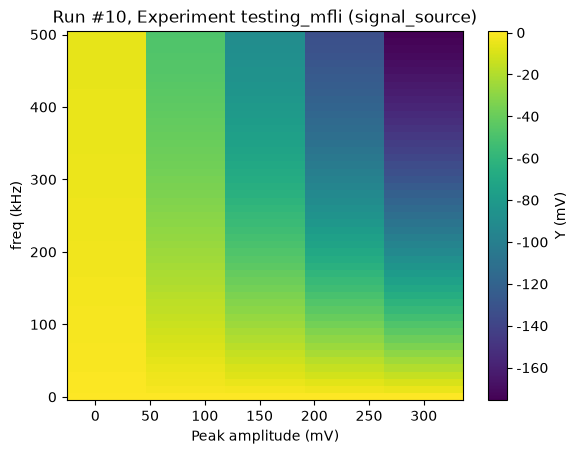

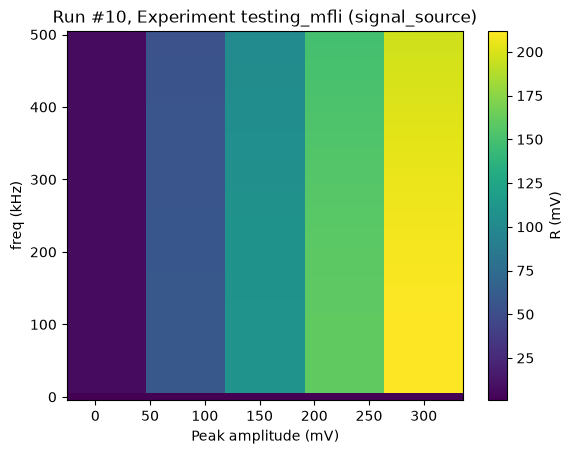

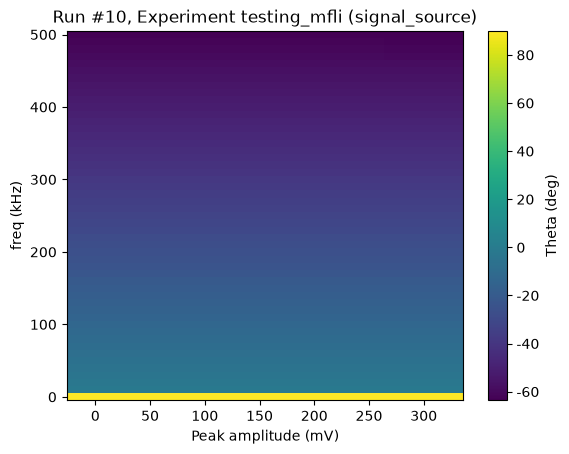

In [22]:
do2d(
        signal_output.amplitude, 0.01, 0.3, 5, 1,
        oscillator.freq, 0, 500e3, 51, 0.1,
        demod.readout,      # In this example, read all four outputs simulaneously.
        exp=experiment,
        measurement_name="points_vs_amplitude_frequency",
        do_plot=True,
        show_progress=True,
    )

## Acquire an X/Y trace versus time

A trace uses the inherited **LabOne DAQ module** to record many samples in
one acquisition. Calling the scalar `x()` parameter repeatedly would instead
make separate point measurements with timing determined partly by Python.

The helper below is notebook code, not an additional driver API. It wraps one
DAQ burst as a QCoDeS `MultiParameter` with two arrays and a shared time axis.
This lets `do0d` and `do1d` save both X and Y with their time setpoints.
It is deliberately configured for the unscaled Signal Input 1 used above.

Each call creates a fresh DAQ module, acquires one continuous burst, and
releases the module even if acquisition fails. Linear grid mode puts X and Y
on the same grid. The requested grid rate is kept below the actual demodulator
streaming rate. Time is calculated from the returned device timestamps using
`lia.clockbase()` (60 MHz on this MFLI, 1.8 GHz on this UHFLI), not Python timing.
A new trace starts its relative time axis at zero.

In [ ]:
class XYTrace(MultiParameter):
    """One DAQ burst of X and Y, for this notebook's voltage-input setup."""

    def __init__(self, name, *, instrument, demod_index, duration=0.5,
                 points=201, timeout=10.0, **kwargs):
        self.device = instrument.root_instrument
        self.demod = instrument
        self.demod_index = demod_index
        self.duration = float(duration)
        self.points = int(points)
        self.timeout = float(timeout)
        if (not np.isfinite([self.duration, self.timeout]).all()
                or self.duration <= 0 or self.points < 2 or self.timeout <= 0):
            raise ValueError("Use positive duration/timeout and at least two points")
        self.time_axis = np.arange(self.points) * self.duration / self.points
        super().__init__(
            name, instrument=instrument,
            names=("trace_x", "trace_y"), labels=("X", "Y"), units=("V", "V"),
            shapes=((self.points,), (self.points,)),
            setpoints=((self.time_axis,), (self.time_axis,)),
            setpoint_names=(("trace_time",), ("trace_time",)),
            setpoint_labels=(("Time from trace start",),) * 2,
            setpoint_units=(("s",),) * 2,
            snapshot_get=False, snapshot_value=False, **kwargs,
        )
        self.metadata.update(duration_s=self.duration, points=self.points,
                             grid_mode="linear", demodulator=demod_index)

    def _check_setup(self):
        if self.demod.adcselect() != 0 or self.device.sigins[0].scaling() != 1:
            raise RuntimeError("This example trace requires unscaled Signal Input 1")
        if not self.demod.enable() or self.demod.trigger() != 0:
            raise RuntimeError("Enable continuous demodulator streaming first")
        if any(ref.enable() and ref.demodselect() == self.demod_index
               for ref in self.device.extrefs):
            raise RuntimeError("The demodulator is reserved for external reference")
        if self.points / self.duration > self.demod.rate():
            raise ValueError("Increase streaming rate or reduce points/duration")

    def get_raw(self):
        self._check_setup()
        paths = [f"/{self.device.serial}/demods/{self.demod_index}/sample.{c}"
                 for c in ("x", "y")]
        module = self.device.session.modules.create_daq_module()
        try:
            module.device(self.device)
            module.type(0)          # Continuous acquisition, no trigger.
            module.grid.mode(2)     # Linear interpolation to a common grid.
            module.grid.rows(1)
            module.count(1)         # One burst per parameter read.
            module.duration(self.duration)
            module.grid.cols(self.points)
            for path in paths:
                module.subscribe(path)
            module.execute()
            module.wait_done(timeout=self.timeout, sleep_time=0.05)
            data = module.read(raw=True)
        finally:
            try:
                module.finish()
                module.unsubscribe("*")
            finally:
                try:
                    module.raw_module.clear()
                finally:
                    module.close()

        if any(path not in data or len(data[path]) != 1 for path in paths):
            raise RuntimeError("Expected one complete burst for each component")
        bursts = [data[path][0] for path in paths]
        values = [np.asarray(burst["value"]) for burst in bursts]
        stamps = [np.asarray(burst["timestamp"]) for burst in bursts]
        if any(a.shape != (1, self.points) for a in values + stamps):
            raise RuntimeError("The DAQ returned an incomplete trace")
        if not all(np.isfinite(a).all() for a in values):
            raise RuntimeError("The DAQ returned non-finite values")
        if not np.array_equal(stamps[0], stamps[1]):
            raise RuntimeError("X and Y timestamps do not match")
        ticks = stamps[0][0]
        if np.any(ticks[1:] <= ticks[:-1]):
            raise RuntimeError("Trace timestamps do not increase")
        times = (ticks - ticks[0]) / float(self.device.clockbase())
        self._check_setup()
        # DataSaver reads these setpoints after get_raw returns, so it saves
        # the actual returned time axis alongside this particular burst.
        self.time_axis = times
        self.setpoints = ((times,), (times,))
        return values[0][0], values[1][0]

In [ ]:
demod.add_parameter(
    "xy_trace", parameter_class=XYTrace, demod_index=demod_index,
    duration=0.5, points=201, timeout=10.0,
)
trace = demod.xy_trace
time.sleep(settle_s)
trace_x, trace_y = trace()  # Acquires a new pair of traces.
trace_time = trace.time_axis.copy()

fig, ax = plt.subplots()
ax.plot(trace_time, trace_x, label="X")
ax.plot(trace_time, trace_y, label="Y")
ax.set(xlabel="Time from trace start (s)", ylabel="Voltage (V)")
ax.legend()
plt.show()

The trace duration is 0.5 s with 201 grid points. The last point is just before
0.5 s, because duration includes the final sample interval. This is a
demodulated, low-pass-filtered trace, not the raw high-speed scope waveform.
R and Theta can also be calculated from the aligned X/Y arrays:

In [ ]:
trace_r = np.hypot(trace_x, trace_y)
trace_theta = np.degrees(np.arctan2(trace_y, trace_x))

## Trace-by-trace acquisition using do0d

`do0d` means **no swept parameter**. The measured parameter can still return
arrays: here it acquires a fresh X/Y trace and saves it against time. It does
not save the previous `trace_x` and `trace_y` arrays from the manual example.

In [ ]:
time.sleep(settle_s)
trace_at_one_frequency, _, _ = do0d(
    trace,
    exp=experiment,
    measurement_name="xy_vs_time",
    do_plot=True,
    use_threads=False,
)

## Trace-by-trace acquisition using do1d

Sweep frequency and record one fresh time trace at each step. There is one
swept parameter, so this uses `do1d`; each returned trace already has its own
time axis. The resulting X and Y datasets are two-dimensional: **frequency
and time since the start of each trace**.

Traces at different frequencies are separate acquisitions, with gaps for
setting, settling and DAQ setup. This is not one uninterrupted time stream.
Keep trace length and units fixed throughout a dataset. To use another
duration/length, create another trace parameter before starting a new dataset.

In [ ]:
frequency_start = oscillator.freq()
try:
    traces_vs_frequency, _, _ = do1d(
        oscillator.freq, 8e3, 12e3, 5, settle_s,
        trace,
        exp=experiment,
        measurement_name="xy_vs_time_and_frequency",
        do_plot=True,
        show_progress=True,
        use_threads=False,
    )
finally:
    oscillator.freq(frequency_start)

# Each result carries both its frequency and its time coordinates.
trace_data = traces_vs_frequency.get_parameter_data()
for name in trace.full_names:
    print(name, {column: array.shape for column, array in trace_data[name].items()})

## Close the connection

In [ ]:
lia.close()